# Pre/post reward-site dimension projection for HPC similarity

This notebook analyzes `pattern` and `position` screen data only.

It implements two pre/post reward-site population-dimension methods:

1. `mixed_c_all`: mix C1/C3/C5, split trials into train/test, train one decoder from one pre/post reward-site window.
2. `c3_train_reward_site`: train on C3 only, test on C1/C5, using one pre/post window around the actual reward site.

Then it recursively removes pre/post reward-site coding dimensions: at each round, an n-fold cross-validation repeated 100 times is performed on the current residual population activity.  The fold-wise decoder directions are sign-aligned and averaged to form the coding dimension for that round.  The process stops when the median held-out/generalization balanced accuracy drops below 60% or the maximum number of dimensions is reached.  The final accumulated subspace is projected out of the canonical A1/A2/B1/B2 population vectors before recomputing Pattern and Position similarity using the same raw-beta template regression as `similarity_analysis.ipynb`.

## Strict window policy

Pre/post reward-site decoding windows are not clipped to the spatial-bin range. If any required window for a file/method would exceed the valid bin index range, that file/method is marked as decoding-invalid and no projected similarity is computed for it. The original, pre-projection similarity is still plotted.

In [78]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
import sys
from typing import Iterable, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import rankdata

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        roc_auc_score,
    )
except Exception as exc:
    LogisticRegression = None
    accuracy_score = None
    balanced_accuracy_score = None
    roc_auc_score = None
    print(f"[Warning] sklearn import failed; falling back to mean-difference decoder. {exc}")


def find_repo_root(start: str | Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "src").exists():
            return path

    # Notebook is usually under repo/src/HPC_2P_analysis/analysis.
    for path in [start, *start.parents]:
        candidate = path / "ZhaoLab-analysis-python"
        if (candidate / "setup.py").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("Cannot find repository root containing setup.py and src/.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from HPC_2P_analysis.utils.config import (  # noqa: E402
    get_one_index,
    index_to_type,
    select_files,
)
from HPC_2P_analysis.utils.loadData import load_screen_data  # noqa: E402

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"SRC_ROOT  = {SRC_ROOT}")

REPO_ROOT = /home/wangym/code/ZhaoLab-analysis-python
SRC_ROOT  = /home/wangym/code/ZhaoLab-analysis-python/src


In [79]:
# =============================================================================
# User-facing configuration
# =============================================================================

DATA_ROOT = REPO_ROOT / "data" / "HPC_2p" / "screen"
TASK_TYPES = ("pattern", "position")
REWARD_MODE = "full"
ANA_BT = ("Correct",)
SCREEN_MODE = "masked"
SESSION_POLICY = "latest"
RANDOM_STATE = 0

# Decoder configuration.
DECODER_KIND = "logistic"  # "logistic" or "mean_difference"
TRAIN_FRACTION = 0.70
MIN_TRAIN_TRIALS_PER_CLASS = 5
MIN_TEST_TRIALS_PER_CLASS = 3
MIN_NEURONS = 5

# Recursive removal.  A newly trained dimension is accepted only when the
# held-out/generalization balanced accuracy is at least this threshold.
# The next round is trained on population activity with all accepted previous
# dimensions removed.
ACCURACY_STOP_THRESHOLD = 0.60
MAX_RECURSIVE_DIMS = 10

# Repeated cross-validation used to estimate each recursive coding dimension.
N_FOLDS = 5
N_REPEATS = 100

# Method 1: one window around each reward site; mix C1/C3/C5.
# Window definition uses reward-zone boundary:
#   pre  = [reward_start - outer, reward_start - inner)
#   post = [reward_end + inner, reward_end + outer)
# The default 10-bin window avoids boundary clipping for reward at zone 1 or zone 5.
METHOD1_OFFSETS = ((0, 9),)

# Method 2: same pre/post reward-site window definition, but train only on C3
# and test on C1/C5.  Temporarily use a single window.
METHOD2_OFFSETS = ((0, 9),)

C_POSITION_TRACKS = {
    1: ("CAB", "CBA"),
    3: ("ACB", "BCA"),
    5: ("ABC", "BAC"),
}
DESTINATION_TRACKS = tuple(
    track
    for c_position in (1, 3, 5)
    for track in C_POSITION_TRACKS[c_position]
)

RULE_COLORS = {
    "pattern": "#6BA3D6",
    "position": "#F0B35B",
}
RULE_LABELS = {
    "pattern": "Pattern rule",
    "position": "Position rule",
}
VALUE_LABELS = {
    "pattern_value": "Pattern similarity",
    "position_value": "Position similarity",
}

print(f"DATA_ROOT = {DATA_ROOT}")

DATA_ROOT = /home/wangym/code/ZhaoLab-analysis-python/data/HPC_2p/screen


In [80]:
# =============================================================================
# Metadata and session selection helpers
# =============================================================================

def extract_session_date_from_name(name: str | Path) -> str | None:
    name = Path(name).name

    match = re.search(
        r"(?<!\d)((?:19|20)\d{2})[-_]?([01]\d)[-_]?([0-3]\d)(?!\d)",
        name,
    )
    if match is not None:
        year, month, day = match.groups()
        return f"{year}-{month}-{day}"

    match = re.search(r"(?<!\d)(\d{2})([01]\d)([0-3]\d)(?!\d)", name)
    if match is not None:
        yy, month, day = match.groups()
        return f"20{yy}-{month}-{day}"

    return None


def infer_mouse_base_id(text: str | Path | None) -> str | None:
    """Extract animal id without session date.

    Examples
    --------
    HP01_2024_12_14 -> HP01
    HPC13_2025_05_23 -> HPC13
    """
    if text is None:
        return None
    text = Path(text).name if isinstance(text, Path) else str(text)
    match = re.search(r"\b(HPC?\d+)\b", text, flags=re.IGNORECASE)
    if match is None:
        return None
    return match.group(1).upper()


def add_session_columns(file_df: pd.DataFrame) -> pd.DataFrame:
    file_df = file_df.copy()

    session_dates = []
    mouse_base_ids = []

    for _, row in file_df.iterrows():
        candidates = [
            row.get("mouse_id", None),
            row.get("file_name", None),
            row.get("source_stem", None),
            row.get("file_path", None),
        ]

        date = None
        mouse_base_id = None
        for candidate in candidates:
            if candidate is None:
                continue
            if date is None:
                date = extract_session_date_from_name(candidate)
            if mouse_base_id is None:
                mouse_base_id = infer_mouse_base_id(candidate)

        session_dates.append(date)
        mouse_base_ids.append(mouse_base_id if mouse_base_id is not None else row.get("mouse_id", None))

    file_df["session_date"] = session_dates
    file_df["session_key"] = file_df["session_date"].str.replace("-", "", regex=False)
    file_df["mouse_base_id"] = mouse_base_ids
    return file_df


def select_one_session_per_mouse_task(
    file_df: pd.DataFrame,
    *,
    session_policy: str = "latest",
) -> pd.DataFrame:
    """Select the last/first session per animal x task x reward_mode.

    The raw screen file names may store mouse_id as mouse+date, e.g.
    HP01_2024_12_14.  Pairing and latest-session selection must therefore use
    mouse_base_id, not the date-containing mouse_id.
    """
    if session_policy not in {"latest", "earliest", "none", None}:
        raise ValueError("session_policy must be 'latest', 'earliest', 'none', or None.")

    file_df = add_session_columns(file_df)

    if session_policy in {"none", None}:
        return file_df.reset_index(drop=True)

    if file_df["session_key"].isna().any():
        bad = file_df.loc[file_df["session_key"].isna(), ["file_path", "file_name", "mouse_id"]]
        raise ValueError("Some files have no parseable session date:\n" + bad.to_string(index=False))

    group_cols = ["mouse_base_id", "task_type"]
    if "reward_mode" in file_df.columns:
        group_cols.append("reward_mode")

    sorted_df = file_df.sort_values(group_cols + ["session_key", "file_name"])
    if session_policy == "latest":
        selected = sorted_df.groupby(group_cols, as_index=False, group_keys=False).tail(1)
    else:
        selected = sorted_df.groupby(group_cols, as_index=False, group_keys=False).head(1)

    print(
        f"[Session selection] policy={session_policy}, "
        f"input files={len(file_df)}, selected files={len(selected)}, "
        f"group_cols={group_cols}"
    )
    return selected.reset_index(drop=True)


def load_pattern_position_file_table(
    data_root: str | Path = DATA_ROOT,
    *,
    task_types: tuple[str, ...] = TASK_TYPES,
    reward_mode: str | None = REWARD_MODE,
    session_policy: str = SESSION_POLICY,
) -> pd.DataFrame:
    file_df = select_files(
        data_root,
        task_type=task_types,
        reward_mode=reward_mode,
        file_kind="pickle",
        recursive=True,
    )
    if len(file_df) == 0:
        raise ValueError(f"No screen pickle files found under: {data_root}")

    file_df = select_one_session_per_mouse_task(
        file_df,
        session_policy=session_policy,
    )

    display_cols = [
        "mouse_base_id", "mouse_id", "task_type", "reward_mode", "session_date", "file_name", "file_path",
    ]
    display(file_df[[c for c in display_cols if c in file_df.columns]])
    return file_df

In [81]:
# =============================================================================
# Track, window, and matrix helpers
# =============================================================================

def first_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[0])


def second_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[1])


def get_zone_interval(zones, zone_index: int, n_position: int) -> tuple[int, int]:
    start = int(np.floor(first_number(zones[zone_index])))
    end = int(np.ceil(second_number(zones[zone_index])))
    start = int(np.clip(start, 0, n_position))
    end = int(np.clip(end, 0, n_position))
    if end <= start:
        raise ValueError(f"Invalid zone interval: zone_index={zone_index}, interval=({start}, {end}).")
    return start, end


def reward_position_to_zone_index(reward_position: int) -> int:
    mapping = {1: 0, 3: 2, 5: 4}
    if reward_position not in mapping:
        raise ValueError(f"reward_position must be 1, 3, or 5; got {reward_position}.")
    return mapping[reward_position]


def get_reward_zone_interval(zones, reward_position: int, n_position: int) -> tuple[int, int]:
    return get_zone_interval(
        zones,
        reward_position_to_zone_index(reward_position),
        n_position,
    )



def make_pre_post_windows(
    zones,
    *,
    reward_position: int,
    n_position: int,
    inner: int,
    outer: int,
) -> tuple[slice, slice]:
    """Make strict pre/post reward-site windows without clipping.

    The requested windows must lie completely inside the valid spatial-bin
    interval [0, n_position).  If either window crosses the boundary, the caller
    should mark the whole file/method as decoding-invalid rather than using a
    truncated window.
    """
    if not (0 <= inner < outer):
        raise ValueError(f"Expected 0 <= inner < outer, got inner={inner}, outer={outer}.")

    reward_start, reward_end = get_reward_zone_interval(
        zones,
        reward_position=reward_position,
        n_position=n_position,
    )

    pre_start = reward_start - outer
    pre_end = reward_start - inner
    post_start = reward_end + inner
    post_end = reward_end + outer

    if pre_start < 0 or pre_end > n_position or post_start < 0 or post_end > n_position:
        raise ValueError(
            "Pre/post reward-site window exceeds valid spatial-bin range; "
            "strict policy forbids clipping. "
            f"reward_position={reward_position}, inner={inner}, outer={outer}, "
            f"n_position={n_position}, pre=({pre_start}, {pre_end}), "
            f"post=({post_start}, {post_end})."
        )

    if pre_end <= pre_start or post_end <= post_start:
        raise ValueError(
            "Invalid pre/post reward-site window. "
            f"reward_position={reward_position}, inner={inner}, outer={outer}, "
            f"pre=({pre_start}, {pre_end}), post=({post_start}, {post_end})."
        )

    return slice(int(pre_start), int(pre_end)), slice(int(post_start), int(post_end))


def track_to_c_position(track_name: str) -> int:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "CBA"}:
        return 1
    if base in {"ACB", "BCA"}:
        return 3
    if base in {"ABC", "BAC"}:
        return 5
    raise ValueError(f"Unknown destination track: {track_name!r}")


def track_to_direction(track_name: str) -> str:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "ACB", "ABC"}:
        return "AB"
    if base in {"CBA", "BCA", "BAC"}:
        return "BA"
    raise ValueError(f"Unknown destination track: {track_name!r}")


def track_reward_position(task_type: str, track_name: str) -> int:
    if task_type == "pattern":
        return track_to_c_position(track_name)
    if task_type == "position":
        return 3
    raise ValueError("This notebook currently supports only pattern and position tasks.")


def get_firing_for_track_behavior(data: dict, track_name: str, behavior_name: str = "Correct") -> np.ndarray:
    tt_idx, bt_idx = get_one_index(data, track_name, behavior_name)
    fr = data["firing"][tt_idx, bt_idx]
    if fr is None:
        return np.empty((0, 0, 0))
    return np.asarray(fr, dtype=float)


def get_index_for_track_behavior(data: dict, track_name: str, behavior_name: str = "Correct") -> np.ndarray:
    tt_idx, bt_idx = get_one_index(data, track_name, behavior_name)
    idx = data["index"][tt_idx, bt_idx]
    return np.asarray(idx).ravel()

In [82]:
# =============================================================================
# Canonical similarity helpers copied from similarity_analysis semantics
# =============================================================================

RULE_LABEL_MAP = {
    "AB_s1e1": "A1",
    "BA_s2e2": "A2",
    "BA_s1e1": "B1",
    "AB_s2e2": "B2",
}
SIMILARITY_LABELS = ["AB_s1e1", "BA_s2e2", "BA_s1e1", "AB_s2e2"]
EDGE_NAMES = ["A1_A2", "A1_B1", "A1_B2", "A2_B1", "A2_B2", "B1_B2"]


def display_rule_labels(labels: list[str]) -> list[str]:
    return [RULE_LABEL_MAP.get(label, "?") for label in labels]


def upper_tri_offdiag(mat: np.ndarray) -> np.ndarray:
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]


def corr_matrix_from_vectors(
    vectors: list[np.ndarray],
    *,
    method: str = "spearman",
    min_neurons: int = 3,
) -> np.ndarray:
    x = np.stack(vectors, axis=0).astype(float)
    valid = np.all(np.isfinite(x), axis=0)
    x = x[:, valid]

    if x.shape[1] < min_neurons:
        return np.full((len(vectors), len(vectors)), np.nan)

    if np.any(np.nanstd(x, axis=1) < 1e-12):
        return np.full((len(vectors), len(vectors)), np.nan)

    if method == "pearson":
        return np.corrcoef(x)

    if method == "spearman":
        x_rank = np.stack([rankdata(row) for row in x], axis=0)
        return np.corrcoef(x_rank)

    raise ValueError("method must be 'pearson' or 'spearman'.")


def make_pure_pattern_position_matrices(display_labels: list[str]) -> tuple[np.ndarray, np.ndarray]:
    patterns = [label[0] for label in display_labels]
    positions = [label[1:] for label in display_labels]
    pure_pattern = np.equal.outer(patterns, patterns).astype(float)
    pure_position = np.equal.outer(positions, positions).astype(float)
    return pure_pattern, pure_position


def compute_pattern_position_value_from_corr(corr: np.ndarray, labels: list[str]) -> dict:
    display_labels = display_rule_labels(labels)
    pure_pattern, pure_position = make_pure_pattern_position_matrices(display_labels)

    y = upper_tri_offdiag(corr)
    x_pattern = upper_tri_offdiag(pure_pattern)
    x_position = upper_tri_offdiag(pure_position)
    valid = np.isfinite(y) & np.isfinite(x_pattern) & np.isfinite(x_position)

    y_fit = y[valid]
    x_pattern_fit = x_pattern[valid]
    x_position_fit = x_position[valid]

    if len(y_fit) < 3:
        return {
            "pattern_value": np.nan,
            "position_value": np.nan,
            "intercept": np.nan,
            "observed_offdiag": y,
        }

    design = np.column_stack([
        np.ones(len(y_fit)),
        x_pattern_fit,
        x_position_fit,
    ])
    beta = np.linalg.lstsq(design, y_fit, rcond=None)[0]

    return {
        "pattern_value": float(beta[1]),
        "position_value": float(beta[2]),
        "intercept": float(beta[0]),
        "observed_offdiag": y,
    }


def get_similarity_zone_bounds(data: dict, n_position: int) -> tuple[int, int, int, int]:
    # Canonical interval mode in similarity_analysis.ipynb:
    # interval 1 = zones[1], interval 2 = zones[3].
    s1, e1 = get_zone_interval(data["zones"], 1, n_position)
    s2, e2 = get_zone_interval(data["zones"], 3, n_position)
    return s1, e1, s2, e2


def orthonormalize_vectors(vectors: list[np.ndarray], *, eps: float = 1e-12) -> np.ndarray | None:
    """Return an orthonormal basis with shape (n_neuron, n_dim)."""
    if vectors is None or len(vectors) == 0:
        return None

    mat = np.column_stack([np.asarray(v, dtype=float) for v in vectors])
    mat = np.where(np.isfinite(mat), mat, 0.0)
    if mat.size == 0:
        return None

    q, r = np.linalg.qr(mat)
    keep = np.abs(np.diag(r)) > eps
    if not np.any(keep):
        return None
    return q[:, keep]


def project_vector(
    v: np.ndarray,
    u: np.ndarray | None = None,
    center: np.ndarray | None = None,
    basis: np.ndarray | None = None,
) -> np.ndarray:
    """Project one population vector away from one direction or a subspace."""
    v = np.asarray(v, dtype=float)
    if basis is None:
        if u is None:
            return v.copy()
        basis = np.asarray(u, dtype=float)[:, None]
    else:
        basis = np.asarray(basis, dtype=float)
        if basis.ndim == 1:
            basis = basis[:, None]

    if center is None:
        center = np.zeros_like(v)
    center = np.asarray(center, dtype=float)

    if basis.shape[0] != v.shape[0]:
        raise ValueError(f"basis neuron dimension {basis.shape[0]} does not match vector length {v.shape[0]}.")

    return v - basis @ (basis.T @ (v - center))


def project_matrix(
    X: np.ndarray,
    *,
    basis: np.ndarray | None,
    center: np.ndarray | None,
) -> np.ndarray:
    """Project rows of X away from an accumulated coding subspace."""
    X = np.asarray(X, dtype=float)
    if basis is None:
        return X.copy()
    basis = np.asarray(basis, dtype=float)
    if basis.ndim == 1:
        basis = basis[:, None]
    if center is None:
        center = np.zeros(X.shape[1], dtype=float)
    center = np.asarray(center, dtype=float)
    return X - (X - center) @ basis @ basis.T


def collect_similarity_vectors_for_tracks(
    data: dict,
    *,
    tracks: Iterable[str],
    behavior_name: str = "Correct",
    u_remove: np.ndarray | None = None,
    center: np.ndarray | None = None,
    basis_remove: np.ndarray | None = None,
) -> dict:
    group_data = {label: [] for label in SIMILARITY_LABELS}
    n_position = None
    n_neuron = None
    trial_counts = {}

    for track_name in tracks:
        fr = get_firing_for_track_behavior(data, track_name, behavior_name)
        if fr.ndim != 3:
            raise ValueError(f"Expected 3D firing for {track_name}, got shape {fr.shape}.")
        if fr.shape[1] == 0:
            trial_counts[track_name] = 0
            continue
        n_neuron = fr.shape[0]
        n_position = fr.shape[2]
        trial_counts[track_name] = fr.shape[1]

    if n_position is None or n_neuron is None:
        raise ValueError("No valid firing data found for requested tracks.")

    s1, e1, s2, e2 = get_similarity_zone_bounds(data, n_position)

    for track_name in tracks:
        fr = get_firing_for_track_behavior(data, track_name, behavior_name)
        if fr.shape[1] == 0:
            continue

        direction = track_to_direction(track_name)
        seg1 = np.nanmean(fr[:, :, s1:e1], axis=2)
        seg2 = np.nanmean(fr[:, :, s2:e2], axis=2)

        group_data[f"{direction}_s1e1"].append(seg1)
        group_data[f"{direction}_s2e2"].append(seg2)

    vectors = {}
    for label in SIMILARITY_LABELS:
        arrays = group_data[label]
        if len(arrays) == 0:
            raise ValueError(f"No data collected for label={label!r}; tracks={tuple(tracks)}.")
        all_trials = np.concatenate(arrays, axis=1)
        v = np.nanmean(all_trials, axis=1)
        vectors[label] = project_vector(v, u_remove, center, basis=basis_remove)

    return {
        "vectors": vectors,
        "labels": SIMILARITY_LABELS.copy(),
        "trial_counts": trial_counts,
        "n_neuron": n_neuron,
        "intervals": {"s1": s1, "e1": e1, "s2": s2, "e2": e2},
    }


def compute_similarity_for_tracks(
    data: dict,
    *,
    tracks: Iterable[str],
    behavior_name: str = "Correct",
    u_remove: np.ndarray | None = None,
    center: np.ndarray | None = None,
    basis_remove: np.ndarray | None = None,
    corr_method: str = "spearman",
) -> dict:
    base = collect_similarity_vectors_for_tracks(
        data,
        tracks=tracks,
        behavior_name=behavior_name,
        u_remove=u_remove,
        center=center,
        basis_remove=basis_remove,
    )
    vectors = base["vectors"]
    corr = corr_matrix_from_vectors(
        [vectors[label] for label in base["labels"]],
        method=corr_method,
    )
    values = compute_pattern_position_value_from_corr(corr, base["labels"])
    edges = dict(zip(EDGE_NAMES, values["observed_offdiag"]))
    return {**base, "corr": corr, "values": values, "edges": edges}


def compute_c_position_similarity_rows(
    data: dict,
    *,
    file_meta: dict,
    method_name: str,
    u_remove: np.ndarray | None,
    center: np.ndarray | None,
    basis_remove: np.ndarray | None = None,
    behavior_name: str = "Correct",
) -> list[dict]:
    rows = []
    for c_position, tracks in C_POSITION_TRACKS.items():
        try:
            result = compute_similarity_for_tracks(
                data,
                tracks=tracks,
                behavior_name=behavior_name,
                u_remove=u_remove,
                center=center,
                basis_remove=basis_remove,
                corr_method="spearman",
            )
            row = {
                **file_meta,
                "method": method_name,
                "c_position": c_position,
                "group": file_meta.get("task_type", "unknown"),
                "pattern_value": result["values"]["pattern_value"],
                "position_value": result["values"]["position_value"],
                "intercept": result["values"]["intercept"],
                "n_neuron": result["n_neuron"],
                "valid": True,
                "invalid_reason": "",
            }
            row.update({f"r_{key}": value for key, value in result["edges"].items()})
            for track, n_trial in result["trial_counts"].items():
                row[f"n_trial_{track}"] = n_trial
        except Exception as exc:
            row = {
                **file_meta,
                "method": method_name,
                "c_position": c_position,
                "group": file_meta.get("task_type", "unknown"),
                "pattern_value": np.nan,
                "position_value": np.nan,
                "intercept": np.nan,
                "n_neuron": np.nan,
                "valid": False,
                "invalid_reason": str(exc),
            }
        rows.append(row)
    return rows

In [83]:
# =============================================================================
# Decoder sample construction
# =============================================================================

@dataclass
class SampleSet:
    X: np.ndarray
    y: np.ndarray
    meta: pd.DataFrame


def build_prepost_reward_site_samples(
    data: dict,
    *,
    task_type: str,
    tracks: Iterable[str] = DESTINATION_TRACKS,
    behavior_name: str = "Correct",
    offsets: tuple[tuple[int, int], ...] = METHOD1_OFFSETS,
) -> SampleSet:
    rows = []
    xs = []
    ys = []

    for track_name in tracks:
        fr = get_firing_for_track_behavior(data, track_name, behavior_name)
        if fr.ndim != 3:
            raise ValueError(f"Expected 3D firing for required track={track_name!r}, got shape {fr.shape}.")
        if fr.shape[1] == 0:
            raise ValueError(f"Required track={track_name!r}, behavior={behavior_name!r} has zero trials; strict decoding forbids using an incomplete file.")

        idx_values = get_index_for_track_behavior(data, track_name, behavior_name)
        if idx_values.size != fr.shape[1]:
            idx_values = np.arange(fr.shape[1])

        n_position = fr.shape[2]
        c_position = track_to_c_position(track_name)
        reward_position = track_reward_position(task_type, track_name)

        for window_id, (inner, outer) in enumerate(offsets):
            pre_slice, post_slice = make_pre_post_windows(
                data["zones"],
                reward_position=reward_position,
                n_position=n_position,
                inner=inner,
                outer=outer,
            )

            pre = np.nanmean(fr[:, :, pre_slice], axis=2).T
            post = np.nanmean(fr[:, :, post_slice], axis=2).T

            for trial_local_idx in range(fr.shape[1]):
                trial_id = str(idx_values[trial_local_idx])
                trial_key = f"{track_name}__{trial_id}"

                xs.append(pre[trial_local_idx])
                ys.append(-1)
                rows.append({
                    "track": track_name,
                    "trial_id": trial_id,
                    "trial_key": trial_key,
                    "label": "pre",
                    "y": -1,
                    "c_position": c_position,
                    "reward_position": reward_position,
                    "window_id": window_id,
                    "inner": inner,
                    "outer": outer,
                })

                xs.append(post[trial_local_idx])
                ys.append(1)
                rows.append({
                    "track": track_name,
                    "trial_id": trial_id,
                    "trial_key": trial_key,
                    "label": "post",
                    "y": 1,
                    "c_position": c_position,
                    "reward_position": reward_position,
                    "window_id": window_id,
                    "inner": inner,
                    "outer": outer,
                })

    if len(xs) == 0:
        raise ValueError("No pre/post reward-site samples were constructed.")

    return SampleSet(
        X=np.vstack(xs).astype(float),
        y=np.asarray(ys, dtype=int),
        meta=pd.DataFrame(rows),
    )


def split_trial_keys_stratified(
    sample_meta: pd.DataFrame,
    *,
    eligible_mask: np.ndarray | None = None,
    train_fraction: float = TRAIN_FRACTION,
    random_state: int = RANDOM_STATE,
) -> tuple[set[str], set[str]]:
    if eligible_mask is None:
        eligible_mask = np.ones(len(sample_meta), dtype=bool)

    d = sample_meta.loc[eligible_mask, ["trial_key", "track", "c_position"]].drop_duplicates()
    if len(d) == 0:
        raise ValueError("No eligible trials for splitting.")

    rng = np.random.default_rng(random_state)
    train_keys = []
    test_keys = []

    for _, ds in d.groupby(["c_position", "track"], sort=True):
        keys = ds["trial_key"].to_numpy()
        keys = keys.copy()
        rng.shuffle(keys)

        if len(keys) < 2:
            test_keys.extend(keys.tolist())
            continue

        n_train = int(np.floor(len(keys) * train_fraction))
        n_train = int(np.clip(n_train, 1, len(keys) - 1))
        train_keys.extend(keys[:n_train].tolist())
        test_keys.extend(keys[n_train:].tolist())

    return set(train_keys), set(test_keys)

In [84]:
# =============================================================================
# Linear decoder fitting and evaluation
# =============================================================================

def _fit_imputer(X_train: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    center = np.nanmean(X_train, axis=0)
    finite_cols = np.isfinite(center)
    center = np.where(np.isfinite(center), center, 0.0)
    return center, finite_cols


def _apply_imputer(X: np.ndarray, center: np.ndarray, finite_cols: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float).copy()
    if X.ndim != 2:
        raise ValueError(f"Expected 2D X, got shape {X.shape}.")
    bad = ~np.isfinite(X)
    if bad.any():
        X[bad] = np.take(center, np.where(bad)[1])
    return X[:, finite_cols]


def fit_linear_decoder(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    decoder_kind: str = DECODER_KIND,
    min_neurons: int = MIN_NEURONS,
    random_state: int = RANDOM_STATE,
) -> dict:
    y_train = np.asarray(y_train, dtype=int)
    if set(np.unique(y_train)) != {-1, 1}:
        raise ValueError(f"Decoder requires both -1 and +1 labels; got {np.unique(y_train)}.")

    center, finite_cols = _fit_imputer(X_train)
    X_fit = _apply_imputer(X_train, center, finite_cols)

    if X_fit.shape[1] < min_neurons:
        raise ValueError(f"Too few finite neurons for decoder: {X_fit.shape[1]} < {min_neurons}.")

    use_logistic = decoder_kind == "logistic" and LogisticRegression is not None

    if use_logistic:
        clf = LogisticRegression(
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            random_state=random_state,
            max_iter=1000,
        )
        clf.fit(X_fit, (y_train > 0).astype(int))
        w_valid = clf.coef_.ravel().astype(float)
        b = float(clf.intercept_[0])
        raw_kind = "logistic"
    else:
        mu_post = np.nanmean(X_fit[y_train == 1], axis=0)
        mu_pre = np.nanmean(X_fit[y_train == -1], axis=0)
        w_valid = mu_post - mu_pre
        b = -0.5 * float(np.dot(w_valid, mu_post + mu_pre))
        raw_kind = "mean_difference"

    # Align sign so that post samples have higher decoder scores in training data.
    train_scores = X_fit @ w_valid + b
    if np.nanmean(train_scores[y_train == 1]) < np.nanmean(train_scores[y_train == -1]):
        w_valid = -w_valid
        b = -b
        train_scores = -train_scores

    norm = float(np.linalg.norm(w_valid))
    if not np.isfinite(norm) or norm < 1e-12:
        raise ValueError("Decoder weight norm is zero or non-finite.")

    w_full = np.zeros(X_train.shape[1], dtype=float)
    w_full[finite_cols] = w_valid
    u_full = w_full / np.linalg.norm(w_full)

    return {
        "decoder_kind": raw_kind,
        "w": w_full,
        "u": u_full,
        "b": b,
        "center": center,
        "finite_cols": finite_cols,
        "n_finite_neurons": int(np.sum(finite_cols)),
    }


def decoder_score(X: np.ndarray, decoder: dict) -> np.ndarray:
    X_fit = _apply_imputer(X, decoder["center"], decoder["finite_cols"])
    w_valid = decoder["w"][decoder["finite_cols"]]
    return X_fit @ w_valid + decoder["b"]


def evaluate_scores(y_true: np.ndarray, scores: np.ndarray, *, threshold: float = 0.0) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    valid = np.isfinite(scores) & np.isin(y_true, [-1, 1])
    y_true = y_true[valid]
    scores = scores[valid]

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return {"accuracy": np.nan, "balanced_accuracy": np.nan, "auc": np.nan, "n": int(len(y_true))}

    y_pred = np.where(scores > threshold, 1, -1)
    acc = float(np.mean(y_pred == y_true))

    if balanced_accuracy_score is not None:
        bal = float(balanced_accuracy_score(y_true, y_pred))
    else:
        bal = float(np.mean([
            np.mean(y_pred[y_true == label] == label)
            for label in [-1, 1]
        ]))

    if roc_auc_score is not None:
        try:
            auc = float(roc_auc_score((y_true > 0).astype(int), scores))
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    return {
        "accuracy": acc,
        "balanced_accuracy": bal,
        "auc": auc,
        "n": int(len(y_true)),
        "n_pre": int(np.sum(y_true == -1)),
        "n_post": int(np.sum(y_true == 1)),
    }


def evaluate_decoder(X: np.ndarray, y: np.ndarray, decoder: dict) -> dict:
    return evaluate_scores(y, decoder_score(X, decoder), threshold=0.0)


def make_average_direction_decoder(
    X_train: np.ndarray,
    y_train: np.ndarray,
    unit_vectors: list[np.ndarray],
) -> dict:
    if len(unit_vectors) == 0:
        raise ValueError("No unit vectors available for averaging.")

    u_sum = np.sum(np.stack(unit_vectors, axis=0), axis=0)
    norm = float(np.linalg.norm(u_sum))
    if not np.isfinite(norm) or norm < 1e-12:
        raise ValueError("Average direction has zero or non-finite norm.")

    u = u_sum / norm
    center, finite_cols = _fit_imputer(X_train)
    X_fit = _apply_imputer(X_train, center, finite_cols)
    u_valid = u[finite_cols]
    scores = X_fit @ u_valid

    # Align sign and choose midpoint threshold using training samples.
    if np.nanmean(scores[y_train == 1]) < np.nanmean(scores[y_train == -1]):
        u = -u
        u_valid = -u_valid
        scores = -scores

    threshold = 0.5 * (
        float(np.nanmean(scores[y_train == 1]))
        + float(np.nanmean(scores[y_train == -1]))
    )

    # Store b such that decoder_score uses threshold zero.
    b = -threshold

    return {
        "decoder_kind": "average_unit_direction",
        "w": u,
        "u": u,
        "b": b,
        "center": center,
        "finite_cols": finite_cols,
        "n_finite_neurons": int(np.sum(finite_cols)),
    }


def fit_linear_decoder_on_projected(
    X_train_raw: np.ndarray,
    y_train: np.ndarray,
    *,
    basis: np.ndarray | None,
    center: np.ndarray | None,
    decoder_kind: str = DECODER_KIND,
    random_state: int = RANDOM_STATE,
) -> dict:
    """Fit one decoder after removing the previously accepted subspace."""
    X_train = project_matrix(
        X_train_raw,
        basis=basis,
        center=center,
    )
    return fit_linear_decoder(
        X_train,
        y_train,
        decoder_kind=decoder_kind,
        random_state=random_state,
    )


def evaluate_decoder_on_projected(
    X_raw: np.ndarray,
    y: np.ndarray,
    decoder: dict,
    *,
    basis: np.ndarray | None,
    center: np.ndarray | None,
) -> dict:
    """Evaluate one decoder on samples after removing previous dimensions."""
    X = project_matrix(
        X_raw,
        basis=basis,
        center=center,
    )
    return evaluate_decoder(X, y, decoder)

In [85]:
# =============================================================================
# Method 1 and Method 2 dimension estimation
# =============================================================================

def make_repeated_stratified_kfold_splits(
    sample_meta: pd.DataFrame,
    *,
    eligible_mask: np.ndarray | None = None,
    n_folds: int = N_FOLDS,
    n_repeats: int = N_REPEATS,
    random_state: int = RANDOM_STATE,
    stratify_cols: tuple[str, ...] = ("c_position", "track"),
) -> list[dict]:
    """Create repeated trial-level stratified K-fold splits.

    The split unit is trial_key, so the pre and post samples from the same trial
    always stay in the same fold.  Stratification is approximate and is done
    within each requested trial-level stratum.
    """
    if eligible_mask is None:
        eligible_mask = np.ones(len(sample_meta), dtype=bool)
    eligible_mask = np.asarray(eligible_mask, dtype=bool)

    trial_cols = ["trial_key", *stratify_cols]
    trial_df = sample_meta.loc[eligible_mask, trial_cols].drop_duplicates().copy()
    if len(trial_df) == 0:
        raise ValueError("No eligible trials for repeated K-fold splitting.")

    n_unique_trials = trial_df["trial_key"].nunique()
    if n_unique_trials < 2:
        raise ValueError("At least two eligible trials are required for K-fold splitting.")

    n_folds_eff = int(min(max(2, n_folds), n_unique_trials))
    rng = np.random.default_rng(random_state)
    splits = []

    for repeat_idx in range(n_repeats):
        fold_to_test_keys = {fold_idx: [] for fold_idx in range(n_folds_eff)}

        for _, ds in trial_df.groupby(list(stratify_cols), sort=True, dropna=False):
            keys = ds["trial_key"].to_numpy().copy()
            rng.shuffle(keys)
            for local_idx, key in enumerate(keys):
                fold_to_test_keys[local_idx % n_folds_eff].append(key)

        eligible_keys = set(trial_df["trial_key"])
        for fold_idx in range(n_folds_eff):
            test_keys = set(fold_to_test_keys[fold_idx])
            train_keys = eligible_keys - test_keys
            if len(test_keys) == 0 or len(train_keys) == 0:
                continue
            test_mask = sample_meta["trial_key"].isin(test_keys).to_numpy()
            train_mask = sample_meta["trial_key"].isin(train_keys).to_numpy()
            splits.append({
                "repeat": repeat_idx,
                "fold": fold_idx,
                "train_mask": train_mask,
                "test_mask": test_mask,
            })

    if len(splits) == 0:
        raise ValueError("Repeated K-fold splitting produced no valid splits.")
    return splits


def make_method1_splits(
    samples: SampleSet,
    *,
    round_idx: int,
    random_state: int,
) -> list[dict]:
    return make_repeated_stratified_kfold_splits(
        samples.meta,
        eligible_mask=np.ones(len(samples.meta), dtype=bool),
        n_folds=N_FOLDS,
        n_repeats=N_REPEATS,
        random_state=random_state + 10007 * round_idx,
        stratify_cols=("c_position", "track"),
    )


def make_method2_splits(
    samples: SampleSet,
    *,
    round_idx: int,
    random_state: int,
) -> list[dict]:
    """Repeated K-fold training splits for C3, with C1/C5 as fixed test set.

    Each fold trains on K-1 folds of C3 trials.  The scientific generalization
    test remains C1/C5.  The held-out C3 fold is stored for diagnostics but does
    not define the recursive stopping criterion.
    """
    cpos = samples.meta["c_position"].to_numpy()
    c3_mask = cpos == 3
    c15_mask = np.isin(cpos, [1, 5])

    c3_splits = make_repeated_stratified_kfold_splits(
        samples.meta,
        eligible_mask=c3_mask,
        n_folds=N_FOLDS,
        n_repeats=N_REPEATS,
        random_state=random_state + 10007 * round_idx,
        stratify_cols=("track",),
    )

    splits = []
    for split in c3_splits:
        splits.append({
            "repeat": split["repeat"],
            "fold": split["fold"],
            "train_mask": split["train_mask"],
            "test_mask": c15_mask.copy(),
            "c3_cv_mask": split["test_mask"],
        })
    return splits


def _nan_summary(values: list[float]) -> dict:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {"median": np.nan, "mean": np.nan, "sem": np.nan, "min": np.nan, "max": np.nan, "n": 0}
    return {
        "median": float(np.nanmedian(x)),
        "mean": float(np.nanmean(x)),
        "sem": float(np.nanstd(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else np.nan,
        "min": float(np.nanmin(x)),
        "max": float(np.nanmax(x)),
        "n": int(len(x)),
    }


def _align_and_average_unit_vectors(unit_vectors: list[np.ndarray]) -> np.ndarray:
    if len(unit_vectors) == 0:
        raise ValueError("No decoder directions available for averaging.")

    aligned = []
    reference = None
    for u in unit_vectors:
        u = np.asarray(u, dtype=float)
        norm = float(np.linalg.norm(u))
        if not np.isfinite(norm) or norm < 1e-12:
            continue
        u = u / norm
        if reference is None:
            reference = u.copy()
        elif float(np.dot(u, reference)) < 0:
            u = -u
        aligned.append(u)

    if len(aligned) == 0:
        raise ValueError("All decoder directions were zero or non-finite.")

    u_mean = np.nanmean(np.stack(aligned, axis=0), axis=0)
    norm = float(np.linalg.norm(u_mean))
    if not np.isfinite(norm) or norm < 1e-12:
        raise ValueError("Mean decoder direction is zero or non-finite.")
    return u_mean / norm


def recursive_train_dimensions_repeated_cv(
    samples: SampleSet,
    *,
    method: str,
    split_maker,
    random_state: int = RANDOM_STATE,
    max_dims: int = MAX_RECURSIVE_DIMS,
    stop_threshold: float = ACCURACY_STOP_THRESHOLD,
) -> tuple[dict | None, dict]:
    """Recursively remove dimensions estimated by repeated K-fold decoding.

    At each round, repeated K-fold splits are generated on the residual activity.
    Each split gives one decoder direction.  Directions are sign-aligned and
    averaged into one round-level coding dimension.  The dimension is accepted
    when the median split-wise test balanced accuracy is at least
    stop_threshold.
    """
    accepted_vectors = []
    round_rows = []
    basis = None
    projection_center = np.nanmean(samples.X, axis=0)
    invalid_reason = ""

    for round_idx in range(max_dims):
        splits = split_maker(samples, round_idx=round_idx, random_state=random_state)
        unit_vectors = []
        split_rows = []

        for split in splits:
            train_mask = np.asarray(split["train_mask"], dtype=bool)
            test_mask = np.asarray(split["test_mask"], dtype=bool)
            y_train = samples.y[train_mask]
            y_test = samples.y[test_mask]

            if np.sum(train_mask) == 0 or np.sum(test_mask) == 0:
                continue
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            try:
                decoder = fit_linear_decoder_on_projected(
                    samples.X[train_mask],
                    y_train,
                    basis=basis,
                    center=projection_center,
                    decoder_kind=DECODER_KIND,
                    random_state=random_state + 100000 * round_idx + 1000 * split["repeat"] + split["fold"],
                )
                train_eval = evaluate_decoder_on_projected(
                    samples.X[train_mask],
                    y_train,
                    decoder,
                    basis=basis,
                    center=projection_center,
                )
                test_eval = evaluate_decoder_on_projected(
                    samples.X[test_mask],
                    y_test,
                    decoder,
                    basis=basis,
                    center=projection_center,
                )

                u_residual = project_vector(
                    decoder["u"],
                    center=np.zeros_like(decoder["u"]),
                    basis=basis,
                )
                norm = float(np.linalg.norm(u_residual))
                if not np.isfinite(norm) or norm < 1e-12:
                    continue
                unit_vectors.append(u_residual / norm)

                cpos = samples.meta["c_position"].to_numpy()
                c_evals = {}
                for c_position in [1, 3, 5]:
                    mask = test_mask & (cpos == c_position)
                    c_evals[c_position] = evaluate_decoder_on_projected(
                        samples.X[mask],
                        samples.y[mask],
                        decoder,
                        basis=basis,
                        center=projection_center,
                    )

                c3_cv_eval = {"balanced_accuracy": np.nan}
                if "c3_cv_mask" in split:
                    c3_cv_mask = np.asarray(split["c3_cv_mask"], dtype=bool)
                    c3_cv_eval = evaluate_decoder_on_projected(
                        samples.X[c3_cv_mask],
                        samples.y[c3_cv_mask],
                        decoder,
                        basis=basis,
                        center=projection_center,
                    )

                split_rows.append({
                    "round": round_idx,
                    "repeat": split["repeat"],
                    "fold": split["fold"],
                    "train_balanced_accuracy": train_eval["balanced_accuracy"],
                    "test_balanced_accuracy": test_eval["balanced_accuracy"],
                    "train_accuracy": train_eval["accuracy"],
                    "test_accuracy": test_eval["accuracy"],
                    "train_auc": train_eval["auc"],
                    "test_auc": test_eval["auc"],
                    "test_c1_balanced_accuracy": c_evals[1]["balanced_accuracy"],
                    "test_c3_balanced_accuracy": c_evals[3]["balanced_accuracy"],
                    "test_c5_balanced_accuracy": c_evals[5]["balanced_accuracy"],
                    "c3_cv_balanced_accuracy": c3_cv_eval["balanced_accuracy"],
                    "n_train_samples": int(np.sum(train_mask)),
                    "n_test_samples": int(np.sum(test_mask)),
                })
            except Exception:
                continue

        if len(split_rows) == 0 or len(unit_vectors) == 0:
            invalid_reason = "no valid repeated K-fold decoder fits"
            break

        train_summary = _nan_summary([row["train_balanced_accuracy"] for row in split_rows])
        test_summary = _nan_summary([row["test_balanced_accuracy"] for row in split_rows])
        c1_summary = _nan_summary([row["test_c1_balanced_accuracy"] for row in split_rows])
        c3_summary = _nan_summary([row["test_c3_balanced_accuracy"] for row in split_rows])
        c5_summary = _nan_summary([row["test_c5_balanced_accuracy"] for row in split_rows])
        c3_cv_summary = _nan_summary([row["c3_cv_balanced_accuracy"] for row in split_rows])
        train_acc_summary = _nan_summary([row["train_accuracy"] for row in split_rows])
        test_acc_summary = _nan_summary([row["test_accuracy"] for row in split_rows])
        train_auc_summary = _nan_summary([row["train_auc"] for row in split_rows])
        test_auc_summary = _nan_summary([row["test_auc"] for row in split_rows])

        median_test = test_summary["median"]
        accepted = bool(np.isfinite(median_test) and median_test >= stop_threshold)
        fraction_above = float(np.nanmean(
            np.asarray([row["test_balanced_accuracy"] for row in split_rows], dtype=float) >= stop_threshold
        ))

        round_row = {
            "round": round_idx,
            "accepted": accepted,
            "n_splits": len(splits),
            "n_valid_splits": len(split_rows),
            "n_repeats": N_REPEATS,
            "n_folds": N_FOLDS,
            "fraction_above_threshold": fraction_above,
            "train_accuracy": train_acc_summary["median"],
            "train_balanced_accuracy": train_summary["median"],
            "train_auc": train_auc_summary["median"],
            "test_accuracy": test_acc_summary["median"],
            "test_balanced_accuracy": test_summary["median"],
            "test_auc": test_auc_summary["median"],
            "test_balanced_accuracy_mean": test_summary["mean"],
            "test_balanced_accuracy_sem": test_summary["sem"],
            "test_c1_balanced_accuracy": c1_summary["median"],
            "test_c3_balanced_accuracy": c3_summary["median"],
            "test_c5_balanced_accuracy": c5_summary["median"],
            "c3_cv_balanced_accuracy": c3_cv_summary["median"],
            "n_train_samples": int(np.nanmedian([row["n_train_samples"] for row in split_rows])),
            "n_test_samples": int(np.nanmedian([row["n_test_samples"] for row in split_rows])),
            "split_rows": split_rows,
        }
        round_rows.append(round_row)

        if not accepted:
            invalid_reason = "stop threshold reached"
            break

        u_round = _align_and_average_unit_vectors(unit_vectors)
        u_round = project_vector(
            u_round,
            center=np.zeros_like(u_round),
            basis=basis,
        )
        norm = float(np.linalg.norm(u_round))
        if not np.isfinite(norm) or norm < 1e-12:
            invalid_reason = "round-averaged direction is linearly dependent on previous dimensions"
            round_rows[-1]["accepted"] = False
            break

        accepted_vectors.append(u_round / norm)
        basis = orthonormalize_vectors(accepted_vectors)

    n_dims = 0 if basis is None else int(basis.shape[1])

    if len(round_rows) == 0:
        return None, {
            "method": method,
            "valid": False,
            "invalid_reason": invalid_reason or "no recursive rounds completed",
            "n_removed_dims": 0,
            "rounds": [],
        }

    final_round = round_rows[-1]
    summary = {
        "method": method,
        "valid": n_dims > 0,
        "invalid_reason": "" if n_dims > 0 else invalid_reason,
        "decoder_kind": "recursive_repeated_kfold_" + DECODER_KIND,
        "n_neuron": int(samples.X.shape[1]),
        "n_finite_neurons": int(samples.X.shape[1]),
        "n_removed_dims": n_dims,
        "stop_threshold": stop_threshold,
        "max_recursive_dims": max_dims,
        "n_repeats": N_REPEATS,
        "n_folds": N_FOLDS,
        "n_train_samples": final_round["n_train_samples"],
        "n_test_samples": final_round["n_test_samples"],
        "train_accuracy": final_round["train_accuracy"],
        "train_balanced_accuracy": final_round["train_balanced_accuracy"],
        "train_auc": final_round["train_auc"],
        "test_accuracy": final_round["test_accuracy"],
        "test_balanced_accuracy": final_round["test_balanced_accuracy"],
        "test_auc": final_round["test_auc"],
        "test_balanced_accuracy_mean": final_round["test_balanced_accuracy_mean"],
        "test_balanced_accuracy_sem": final_round["test_balanced_accuracy_sem"],
        "fraction_above_threshold": final_round["fraction_above_threshold"],
        "test_c1_balanced_accuracy": final_round["test_c1_balanced_accuracy"],
        "test_c3_balanced_accuracy": final_round["test_c3_balanced_accuracy"],
        "test_c5_balanced_accuracy": final_round["test_c5_balanced_accuracy"],
        "c3_cv_balanced_accuracy": final_round["c3_cv_balanced_accuracy"],
        "rounds": round_rows,
    }

    decoder_out = {
        "decoder_kind": summary["decoder_kind"],
        "basis": basis,
        "u": None if basis is None else basis[:, 0],
        "center": projection_center,
        "rounds": round_rows,
    }
    return decoder_out, summary


def fit_method1_mixed_c_all(
    data: dict,
    *,
    task_type: str,
    random_state: int = RANDOM_STATE,
) -> tuple[dict | None, dict]:
    samples = build_prepost_reward_site_samples(
        data,
        task_type=task_type,
        tracks=DESTINATION_TRACKS,
        behavior_name=ANA_BT[0],
        offsets=METHOD1_OFFSETS,
    )

    decoder, summary = recursive_train_dimensions_repeated_cv(
        samples,
        method="mixed_c_all",
        split_maker=make_method1_splits,
        random_state=random_state,
    )
    summary["offsets"] = str(METHOD1_OFFSETS)
    return decoder, summary


def fit_method2_c3_train_reward_site(
    data: dict,
    *,
    task_type: str,
    random_state: int = RANDOM_STATE,
) -> tuple[dict | None, dict]:
    """Repeated K-fold C3 training with C1/C5 generalization testing."""
    samples = build_prepost_reward_site_samples(
        data,
        task_type=task_type,
        tracks=DESTINATION_TRACKS,
        behavior_name=ANA_BT[0],
        offsets=METHOD2_OFFSETS,
    )

    decoder, summary = recursive_train_dimensions_repeated_cv(
        samples,
        method="c3_train_reward_site",
        split_maker=make_method2_splits,
        random_state=random_state,
    )
    summary["offsets"] = str(METHOD2_OFFSETS)
    return decoder, summary


def fit_projection_dimension(data: dict, *, task_type: str, method: str, random_state: int) -> tuple[dict | None, dict]:
    try:
        if method == "mixed_c_all":
            return fit_method1_mixed_c_all(data, task_type=task_type, random_state=random_state)
        if method == "c3_train_reward_site":
            return fit_method2_c3_train_reward_site(data, task_type=task_type, random_state=random_state)
        raise ValueError(f"Unknown method: {method!r}")
    except Exception as exc:
        return None, {
            "method": method,
            "valid": False,
            "invalid_reason": str(exc),
        }

In [86]:
# =============================================================================
# Statistics and plotting helpers adapted from similarity_analysis.ipynb/run_2
# =============================================================================

def p_to_stars(p):
    if p is None or not np.isfinite(p):
        return "n.s."
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def sem_omit_nan(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return np.nan
    return float(np.nanstd(x, ddof=1) / np.sqrt(len(x)))


def remove_top_right_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def get_strict_paired_arrays(
    df: pd.DataFrame,
    *,
    group1: str,
    group2: str,
    value_name: str,
    subject_col: str = "mouse_base_id",
    group_col: str = "group",
) -> tuple[np.ndarray, np.ndarray, list]:
    d1 = df.loc[df[group_col] == group1, [subject_col, value_name]].copy()
    d2 = df.loc[df[group_col] == group2, [subject_col, value_name]].copy()
    d1 = d1[np.isfinite(d1[value_name].to_numpy(float))]
    d2 = d2[np.isfinite(d2[value_name].to_numpy(float))]

    s1 = set(d1[subject_col])
    s2 = set(d2[subject_col])
    if s1 != s2:
        raise ValueError(
            "Paired comparison requires exactly matched subjects. "
            f"Only in {group1}: {sorted(s1 - s2)}; only in {group2}: {sorted(s2 - s1)}"
        )

    subjects = sorted(s1)
    y1 = d1.set_index(subject_col).loc[subjects, value_name].to_numpy(float)
    y2 = d2.set_index(subject_col).loc[subjects, value_name].to_numpy(float)
    return y1, y2, subjects


def filter_to_common_paired_subjects(
    df: pd.DataFrame,
    *,
    group1: str = "pattern",
    group2: str = "position",
    value_names: tuple[str, ...] = ("pattern_value", "position_value"),
    subject_col: str = "mouse_base_id",
    group_col: str = "group",
) -> pd.DataFrame:
    df_use = df[df[group_col].isin([group1, group2])].copy()
    subject_sets = {}
    for group in [group1, group2]:
        d = df_use[df_use[group_col] == group]
        finite = np.ones(len(d), dtype=bool)
        for value_name in value_names:
            finite &= np.isfinite(d[value_name].to_numpy(float))
        subject_sets[group] = set(d.loc[finite, subject_col])
    common = subject_sets[group1] & subject_sets[group2]
    print("[Paired subject filtering]")
    print(f"{group1}: n={len(subject_sets[group1])}")
    print(f"{group2}: n={len(subject_sets[group2])}")
    print(f"common: n={len(common)}")
    print(f"only in {group1}: {sorted(subject_sets[group1] - common)}")
    print(f"only in {group2}: {sorted(subject_sets[group2] - common)}")
    return df_use[df_use[subject_col].isin(common)].reset_index(drop=True)


def run_paired_wilcoxon(df: pd.DataFrame, *, value_name: str) -> dict:
    y1, y2, subjects = get_strict_paired_arrays(
        df,
        group1="pattern",
        group2="position",
        value_name=value_name,
    )
    if len(y1) < 2:
        stat, p = np.nan, np.nan
    elif np.allclose(y1, y2):
        stat, p = 0.0, 1.0
    else:
        stat, p = stats.wilcoxon(y1, y2, alternative="two-sided", zero_method="wilcox", method="auto")
    return {
        "value_name": value_name,
        "test": "wilcoxon",
        "n": len(subjects),
        "stat": float(stat) if np.isfinite(stat) else np.nan,
        "p": float(p) if np.isfinite(p) else np.nan,
        "stars": p_to_stars(p),
        "median_diff_position_minus_pattern": float(np.nanmedian(y2 - y1)) if len(y1) else np.nan,
    }


def summarize_cpos_for_errorbar(d: pd.DataFrame, *, value_name: str) -> pd.DataFrame:
    rows = []
    for (method, group, c_position), ds in d.groupby(["method", "group", "c_position"], sort=True):
        y = ds[value_name].to_numpy(float)
        y = y[np.isfinite(y)]
        rows.append({
            "method": method,
            "group": group,
            "c_position": int(c_position),
            "mean": float(np.nanmean(y)) if len(y) else np.nan,
            "sem": sem_omit_nan(y),
            "n": int(len(y)),
        })
    return pd.DataFrame(rows)


def plot_c_position_lines(
    cpos_df: pd.DataFrame,
    *,
    method: str,
    value_name: str,
    figsize=(5.8, 4.6),
):
    d = cpos_df[
        cpos_df["method"].isin(["original", method])
        & cpos_df["valid"]
    ].copy()
    summary = summarize_cpos_for_errorbar(d, value_name=value_name)
    x_positions = [1, 3, 5]
    x = np.arange(len(x_positions))

    fig, ax = plt.subplots(figsize=figsize)

    for group in ["pattern", "position"]:
        color = RULE_COLORS[group]
        for method_name, linestyle, alpha, label_suffix in [
            ("original", "--", 0.80, "original"),
            (method, "-", 1.00, "projected"),
        ]:
            dg = summary[(summary["group"] == group) & (summary["method"] == method_name)]
            if len(dg) == 0:
                continue
            dg = dg.set_index("c_position").reindex(x_positions)
            y = dg["mean"].to_numpy(float)
            yerr = dg["sem"].to_numpy(float)
            n_text = int(np.nanmin(dg["n"].to_numpy(float))) if np.any(np.isfinite(dg["n"].to_numpy(float))) else 0
            ax.errorbar(
                x,
                y,
                yerr=yerr,
                color=color,
                linestyle=linestyle,
                linewidth=2.6 if method_name == method else 2.0,
                marker="o",
                markersize=6,
                capsize=3,
                alpha=alpha,
                label=f"{RULE_LABELS[group]} {label_suffix} (n≈{n_text})",
            )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.35)
    ax.set_xticks(x, ["C1", "C3", "C5"])
    ax.set_xlabel("C position")
    ax.set_ylabel(VALUE_LABELS[value_name])
    ax.set_title(f"{method}: original vs projected {VALUE_LABELS[value_name]}")
    ax.legend(frameon=False, fontsize=8)
    remove_top_right_spines(ax)
    fig.tight_layout()
    plt.show()
    return fig, ax, summary


def plot_pattern_position_paired_box(
    cpos_df: pd.DataFrame,
    *,
    method: str,
    c_position: int = 3,
    figsize=(7.2, 4.2),
):
    d = cpos_df[
        (cpos_df["method"] == method)
        & (cpos_df["c_position"] == c_position)
        & cpos_df["valid"]
    ].copy()
    d = filter_to_common_paired_subjects(d, group1="pattern", group2="position")

    value_names = ("pattern_value", "position_value")
    ylabels = ("Pattern similarity", "Position similarity")
    fig, axes = plt.subplots(1, 2, figsize=figsize, squeeze=False)
    axes = axes[0]
    rng = np.random.default_rng(0)
    stats_rows = []

    for ax, value_name, ylabel in zip(axes, value_names, ylabels):
        data = []
        for group in ["pattern", "position"]:
            y = d.loc[d["group"] == group, value_name].to_numpy(float)
            y = y[np.isfinite(y)]
            data.append(y)

        box = ax.boxplot(
            data,
            positions=[1, 2],
            widths=0.42,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="k", lw=2),
            boxprops=dict(edgecolor="k", lw=1.2),
            whiskerprops=dict(color="k", lw=1.2),
            capprops=dict(color="k", lw=1.2),
        )
        for patch, group in zip(box["boxes"], ["pattern", "position"]):
            patch.set_facecolor(RULE_COLORS[group])
            patch.set_alpha(0.65)

        y_pattern, y_position, subjects = get_strict_paired_arrays(
            d,
            group1="pattern",
            group2="position",
            value_name=value_name,
        )
        for yp, yq in zip(y_pattern, y_position):
            ax.plot([1.18, 1.82], [yp, yq], color="0.70", alpha=0.55, lw=0.9, zorder=1)

        for xpos, group, y in zip([1, 2], ["pattern", "position"], data):
            jitter = rng.normal(0, 0.055, size=len(y))
            ax.scatter(
                np.ones(len(y)) * xpos + jitter,
                y,
                s=34,
                color=RULE_COLORS[group],
                alpha=0.9,
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )

        stat_row = run_paired_wilcoxon(d, value_name=value_name)
        stats_rows.append(stat_row)

        ymin, ymax = ax.get_ylim()
        span = max(ymax - ymin, 1e-6)
        ybar = ymax + 0.05 * span
        ax.plot([1, 1, 2, 2], [ybar, ybar + 0.025 * span, ybar + 0.025 * span, ybar], color="black", lw=1.2, clip_on=False)
        ax.text(1.5, ybar + 0.035 * span, stat_row["stars"], ha="center", va="bottom", fontsize=11)
        ax.set_ylim(ymin, ybar + 0.14 * span)

        ax.set_xticks([1, 2], [f"Pattern\n(n={len(data[0])})", f"Position\n(n={len(data[1])})"])
        ax.set_ylabel(ylabel)
        remove_top_right_spines(ax)

    fig.suptitle(f"{method}: Pattern vs Position projected similarity, C{c_position}")
    fig.tight_layout()
    plt.show()

    stats_df = pd.DataFrame(stats_rows)
    display(stats_df)
    return {"figure": fig, "axes": axes, "stats": stats_df, "df_paired": d}

In [87]:
# =============================================================================
# Main analysis runner
# =============================================================================

def make_file_meta(file_row: pd.Series, data: dict) -> dict:
    meta = dict(data.get("file_info", {}))
    for col, value in file_row.items():
        meta[col] = value
    if "mouse_base_id" not in meta or pd.isna(meta.get("mouse_base_id")):
        meta["mouse_base_id"] = infer_mouse_base_id(meta.get("mouse_id")) or meta.get("mouse_id")
    return meta


def analyze_one_file(file_row: pd.Series, *, random_state: int = RANDOM_STATE) -> tuple[list[dict], list[dict]]:
    file_path = Path(file_row["file_path"])
    data = load_screen_data(file_path, screen_mode=SCREEN_MODE)
    file_meta = make_file_meta(file_row, data)
    task_type = str(file_meta["task_type"])

    decoder_rows = []
    similarity_rows = []

    # Baseline: canonical similarity before projection.
    similarity_rows.extend(
        compute_c_position_similarity_rows(
            data,
            file_meta=file_meta,
            method_name="original",
            u_remove=None,
            center=None,
            behavior_name=ANA_BT[0],
        )
    )

    print("\n" + "=" * 100)
    print(f"File: {file_path}")
    print(
        f"mouse={file_meta.get('mouse_id', 'NA')} | "
        f"task={task_type} | "
        f"date={file_meta.get('session_date', 'NA')} | "
        f"reward={file_meta.get('reward_mode', 'NA')}"
    )

    for method in ["mixed_c_all", "c3_train_reward_site"]:
        decoder, summary = fit_projection_dimension(
            data,
            task_type=task_type,
            method=method,
            random_state=random_state,
        )
        decoder_row = {**file_meta, **summary}
        decoder_rows.append(decoder_row)

        if summary.get("valid", False):
            print(
                f"[{method}] valid | decoder={summary.get('decoder_kind')} | "
                f"n_removed_dims={summary.get('n_removed_dims', np.nan)} | "
                f"folds={summary.get('n_folds', np.nan)} x repeats={summary.get('n_repeats', np.nan)} | "
                f"final median train bal.acc={summary.get('train_balanced_accuracy', np.nan):.3f}, "
                f"final median test bal.acc={summary.get('test_balanced_accuracy', np.nan):.3f}, "
                f"C1={summary.get('test_c1_balanced_accuracy', np.nan):.3f}, "
                f"C3={summary.get('test_c3_balanced_accuracy', np.nan):.3f}, "
                f"C5={summary.get('test_c5_balanced_accuracy', np.nan):.3f}"
            )
            if True:
                print("  recursive rounds:")
                for row in summary.get("rounds", []):
                    print(
                        f"    round {row['round']}: "
                        f"accepted={row['accepted']} | "
                        f"valid_splits={row.get('n_valid_splits', np.nan)} | "
                        f"frac≥thr={row.get('fraction_above_threshold', np.nan):.2f} | "
                        f"median train={row['train_balanced_accuracy']:.3f}, "
                        f"median test={row['test_balanced_accuracy']:.3f}, "
                        f"C1={row['test_c1_balanced_accuracy']:.3f}, "
                        f"C3={row['test_c3_balanced_accuracy']:.3f}, "
                        f"C5={row['test_c5_balanced_accuracy']:.3f}"
                    )

            similarity_rows.extend(
                compute_c_position_similarity_rows(
                    data,
                    file_meta=file_meta,
                    method_name=method,
                    u_remove=None,
                    center=decoder["center"],
                    basis_remove=decoder["basis"],
                    behavior_name=ANA_BT[0],
                )
            )
        else:
            print(f"[{method}] INVALID: {summary.get('invalid_reason', '')}")
            # Do not compute projected rows for decoding-invalid files/methods.
            # The baseline original rows were already added above and will still
            # be included in original (dashed) curves.  This prevents truncated
            # or incomplete decoding windows from contributing to projected
            # similarity.

    return decoder_rows, similarity_rows


def run_reward_site_projection_analysis(
    *,
    data_root: str | Path = DATA_ROOT,
    random_state: int = RANDOM_STATE,
) -> dict:
    file_df = load_pattern_position_file_table(data_root)

    all_decoder_rows = []
    all_similarity_rows = []

    for row_idx, file_row in file_df.reset_index(drop=True).iterrows():
        decoder_rows, similarity_rows = analyze_one_file(
            file_row,
            random_state=random_state + row_idx,
        )
        all_decoder_rows.extend(decoder_rows)
        all_similarity_rows.extend(similarity_rows)

    decoder_df = pd.DataFrame(all_decoder_rows)
    cpos_similarity_df = pd.DataFrame(all_similarity_rows)

    print("\nDecoder accuracy summary:")
    accuracy_cols = [
        "mouse_base_id", "mouse_id", "task_type", "session_date", "method", "valid",
        "n_removed_dims", "n_folds", "n_repeats", "fraction_above_threshold",
        "train_balanced_accuracy", "test_balanced_accuracy", "test_balanced_accuracy_sem",
        "test_c1_balanced_accuracy", "test_c3_balanced_accuracy", "test_c5_balanced_accuracy", "c3_cv_balanced_accuracy",
        "n_neuron", "n_finite_neurons", "stop_threshold", "invalid_reason",
    ]
    display(decoder_df[[c for c in accuracy_cols if c in decoder_df.columns]])

    print("\nProjected C-position similarity summary:")
    sim_cols = [
        "mouse_base_id", "mouse_id", "task_type", "session_date", "method", "c_position", "valid",
        "pattern_value", "position_value", "intercept", "n_neuron", "invalid_reason",
    ]
    display(cpos_similarity_df[[c for c in sim_cols if c in cpos_similarity_df.columns]])

    plots = {}
    for method in ["mixed_c_all", "c3_train_reward_site"]:
        plots[(method, "cpos_pattern")] = plot_c_position_lines(
            cpos_similarity_df,
            method=method,
            value_name="pattern_value",
        )
        plots[(method, "cpos_position")] = plot_c_position_lines(
            cpos_similarity_df,
            method=method,
            value_name="position_value",
        )
        plots[(method, "paired_c3")] = plot_pattern_position_paired_box(
            cpos_similarity_df,
            method=method,
            c_position=3,
        )

    return {
        "file_df": file_df,
        "decoder_df": decoder_df,
        "cpos_similarity_df": cpos_similarity_df,
        "plots": plots,
    }

[Session selection] policy=latest, input files=29, selected files=22, group_cols=['mouse_base_id', 'task_type', 'reward_mode']


,mouse_base_id,mouse_id,task_type,reward_mode,session_date,file_name,file_path
0,HP01,HP01_2024_12_14,pattern,full,2024-12-14,HP01_2024-12-14_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
1,HP01,HP01_2024_12_24,position,full,2024-12-24,HP01_2024-12-24_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
2,HP02,HP02_2024_12_29,pattern,full,2024-12-29,HP02_2024-12-29_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
3,HP02,HP02_2024_12_23,position,full,2024-12-23,HP02_2024-12-23_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
4,HP03,HP03_2025_01_22,pattern,full,2025-01-22,HP03_2025-01-22_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
5,HP07,HP07_2025_03_08,pattern,full,2025-03-08,HP07_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
6,HP07,HP07_2025_03_11,position,full,2025-03-11,HP07_2025-03-11_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
7,HP08,HP08_2025_03_08,pattern,full,2025-03-08,HP08_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
8,HP08,HP08_2025_03_13,position,full,2025-03-13,HP08_2025-03-13_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
9,HP24,HP24_2025_08_01,pattern,full,2025-08-01,HP24_2025-08-01_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...



File: /home/wangym/code/ZhaoLab-analysis-python/data/HPC_2p/screen/HP01/HP01_2024-12-14_pattern_screen.pkl
mouse=HP01_2024_12_14 | task=pattern | date=2024-12-14 | reward=full
[mixed_c_all] valid | decoder=recursive_repeated_kfold_logistic | n_removed_dims=1 | folds=5 x repeats=100 | final median train bal.acc=1.000, final median test bal.acc=0.462, C1=0.214, C3=0.429, C5=0.667
  recursive rounds:
    round 0: accepted=True | valid_splits=500 | frac≥thr=1.00 | median train=1.000, median test=1.000, C1=1.000, C3=1.000, C5=1.000
    round 1: accepted=False | valid_splits=500 | frac≥thr=0.04 | median train=1.000, median test=0.462, C1=0.214, C3=0.429, C5=0.667
[c3_train_reward_site] valid | decoder=recursive_repeated_kfold_logistic | n_removed_dims=1 | folds=5 x repeats=100 | final median train bal.acc=1.000, final median test bal.acc=0.567, C1=0.507, C3=nan, C5=0.617
  recursive rounds:
    round 0: accepted=True | valid_splits=500 | frac≥thr=1.00 | median train=1.000, median test=0.982

,mouse_base_id,mouse_id,task_type,session_date,method,valid,n_removed_dims,n_folds,n_repeats,fraction_above_threshold,...,test_balanced_accuracy,test_balanced_accuracy_sem,test_c1_balanced_accuracy,test_c3_balanced_accuracy,test_c5_balanced_accuracy,c3_cv_balanced_accuracy,n_neuron,n_finite_neurons,stop_threshold,invalid_reason
0,HP01,HP01_2024_12_14,pattern,2024-12-14,mixed_c_all,True,1,5,100,0.044,...,0.461538,0.003609,0.214286,0.428571,0.666667,NaN,1154,1154,0.6,
1,HP01,HP01_2024_12_14,pattern,2024-12-14,c3_train_reward_site,True,1,5,100,0.378,...,0.567073,0.005711,0.507143,NaN,0.617021,0.133929,1154,1154,0.6,
2,HP01,HP01_2024_12_24,position,2024-12-24,mixed_c_all,True,3,5,100,0.442,...,0.571429,0.006805,0.555556,0.636364,0.600000,NaN,1040,1040,0.6,
3,HP01,HP01_2024_12_24,position,2024-12-24,c3_train_reward_site,True,5,5,100,0.490,...,0.597826,0.003783,0.602041,NaN,0.604651,0.090909,1040,1040,0.6,
4,HP02,HP02_2024_12_29,pattern,2024-12-29,mixed_c_all,True,1,5,100,0.310,...,0.552632,0.004542,0.500000,0.375000,0.642857,NaN,478,478,0.6,
5,HP02,HP02_2024_12_29,pattern,2024-12-29,c3_train_reward_site,True,1,5,100,0.466,...,0.578125,0.006189,0.607143,NaN,0.555556,0.250000,478,478,0.6,
6,HP02,HP02_2024_12_23,position,2024-12-23,mixed_c_all,True,2,5,100,0.144,...,0.500000,0.004040,0.437500,0.500000,0.571429,NaN,565,565,0.6,
7,HP02,HP02_2024_12_23,position,2024-12-23,c3_train_reward_site,True,10,5,100,0.698,...,0.642857,0.004037,0.644737,NaN,0.656250,0.142857,565,565,0.6,
8,HP03,HP03_2025_01_22,pattern,2025-01-22,mixed_c_all,True,2,5,100,0.224,...,0.535714,0.003612,0.625000,0.500000,0.500000,NaN,793,793,0.6,
9,HP03,HP03_2025_01_22,pattern,2025-01-22,c3_train_reward_site,True,5,5,100,0.470,...,0.591463,0.006023,0.587500,NaN,0.595238,0.055556,793,793,0.6,



Projected C-position similarity summary:


,mouse_base_id,mouse_id,task_type,session_date,method,c_position,valid,pattern_value,position_value,intercept,n_neuron,invalid_reason
0,HP01,HP01_2024_12_14,pattern,2024-12-14,original,1,True,0.503286,0.176177,-0.014207,1154,
1,HP01,HP01_2024_12_14,pattern,2024-12-14,original,3,True,0.415069,0.201950,0.018645,1154,
2,HP01,HP01_2024_12_14,pattern,2024-12-14,original,5,True,0.448191,0.190109,0.035861,1154,
3,HP01,HP01_2024_12_14,pattern,2024-12-14,mixed_c_all,1,True,0.503218,0.174933,-0.013920,1154,
4,HP01,HP01_2024_12_14,pattern,2024-12-14,mixed_c_all,3,True,0.415113,0.203251,0.016230,1154,
...,...,...,...,...,...,...,...,...,...,...,...,...
193,HPC14,HPC14_2025_05_22,position,2025-05-22,mixed_c_all,3,True,0.327971,0.273282,-0.192350,871,
194,HPC14,HPC14_2025_05_22,position,2025-05-22,mixed_c_all,5,True,0.267262,0.278722,-0.159757,871,
195,HPC14,HPC14_2025_05_22,position,2025-05-22,c3_train_reward_site,1,True,0.167277,0.169060,0.198091,871,
196,HPC14,HPC14_2025_05_22,position,2025-05-22,c3_train_reward_site,3,True,0.214129,0.165603,0.222216,871,


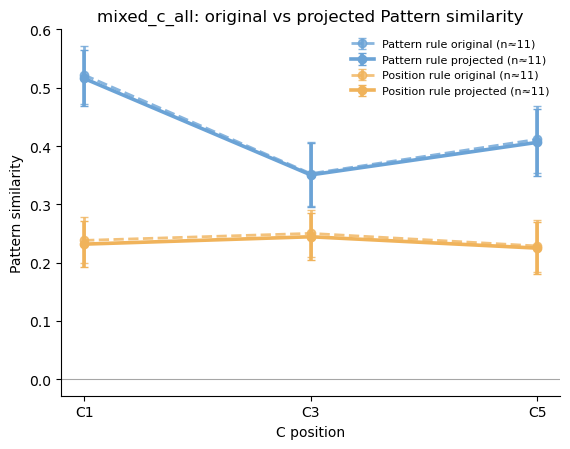

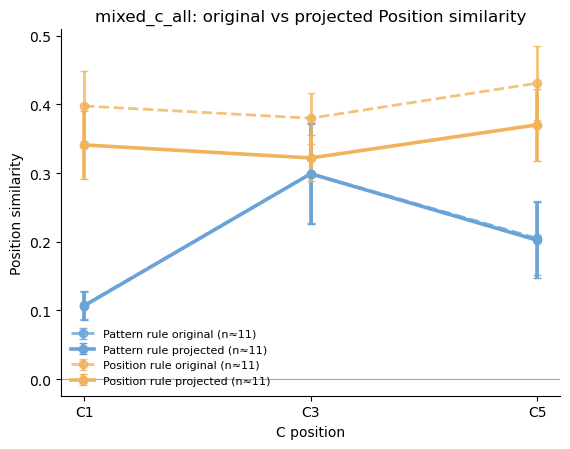

[Paired subject filtering]
pattern: n=11
position: n=11
common: n=10
only in pattern: ['HP03']
only in position: ['HP31']


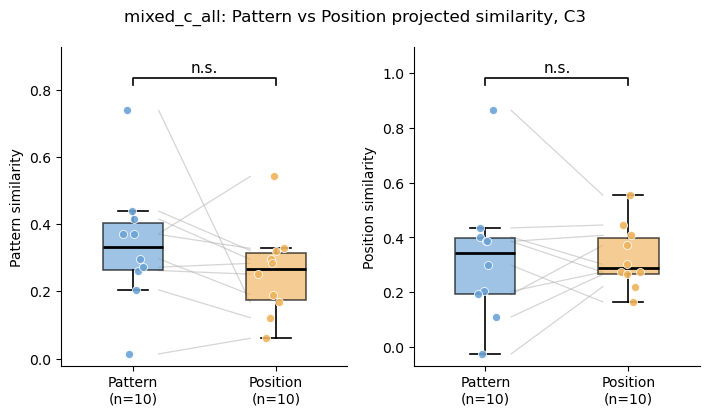

,value_name,test,n,stat,p,stars,median_diff_position_minus_pattern
0,pattern_value,wilcoxon,10,15.0,0.232422,n.s.,-0.062056
1,position_value,wilcoxon,10,25.0,0.845703,n.s.,0.016262


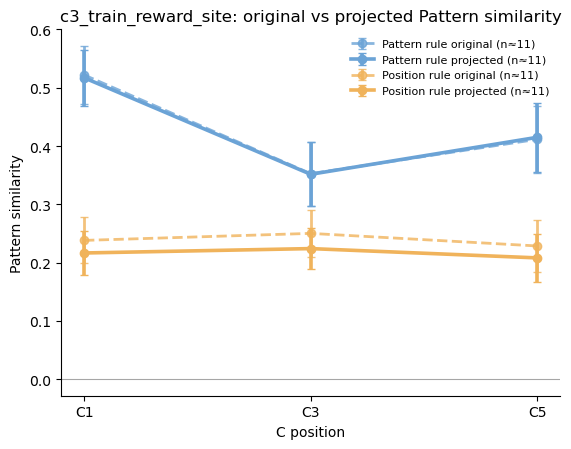

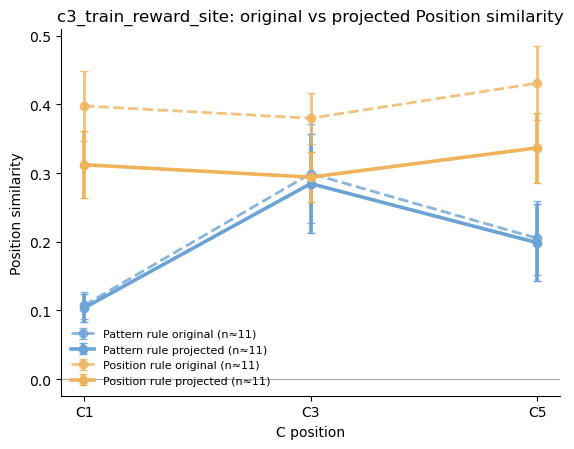

[Paired subject filtering]
pattern: n=11
position: n=11
common: n=10
only in pattern: ['HP03']
only in position: ['HP31']


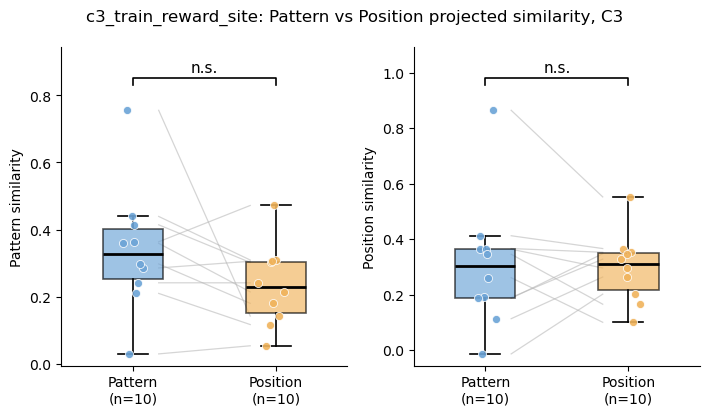

,value_name,test,n,stat,p,stars,median_diff_position_minus_pattern
0,pattern_value,wilcoxon,10,10.0,0.083984,n.s.,-0.102574
1,position_value,wilcoxon,10,25.0,0.845703,n.s.,-0.029817


In [88]:
# Run the full analysis.
# If you only want to load definitions first, set RUN_ANALYSIS = False.
RUN_ANALYSIS = True

if RUN_ANALYSIS:
    result = run_reward_site_projection_analysis()